# Orbital Network Atlas: how it was built

A write-up of the **Orbital Network Atlas**, a live 3D atlas of satellite-to-ground-station data
links, with a similarity map ("datamap") of the whole dataset. Built 26–27 September 2026 as a
companion to the Subsea Cable Atlas.

**Live app (PWA):** https://bobroberts2639.github.io/Pangolin-Orbital-Network-Atlas-datamap-with-pwa/

This notebook reads the shipped payload (`data/orbital.json`) and reproduces the key numbers and
figures behind it. Each section says what was done, why, and how it was checked.

1. Question and design
2. Data sources
3. What is in the atlas
4. Satellite positions: published elements to a browser
5. The similarity map (datamap)
6. The ground segment: curated sites, FCC licences and temporary authorities
7. The link model
8. Coverage heatmap
9. Refresh, hosting and the PWA
10. Validation and known gaps
11. Rebuilding from scratch

Run it from the repository's `notebooks/` folder. Sections 4 and 8 download current elements from
GitHub mirrors; everything else works offline. You need `numpy pandas matplotlib sgp4`.

In [1]:
import json, math, os, sys, collections, datetime as dt
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
D = json.load(open(os.path.join(ROOT, 'data', 'orbital.json')))
SA, GS = D['sats'], D['stations']
CONST = pd.DataFrame(D['const'])
print(f"payload built {D['built']} · elements as of {D['elements_as_of']}")
print(f"{len(SA['id']):,} satellites · {len(GS['name']):,} ground sites")

# Figure style: dark surface, text in neutral ink (never series colour).
# The categorical palette is the dataviz reference palette (dark steps), validated for this surface:
# five slots pass the adjacent CVD / normal-vision checks for stacked bars, and the first three pass
# all-pairs for scatter plots.
SURF, INK, INK2, GRID = '#0d1118', '#e6ebf2', '#9aa7b8', '#243042'
CAT = ['#3987e5', '#d95926', '#199e70', '#c98500', '#d55181']
OTHER = '#5d6776'
AMBER = LinearSegmentedColormap.from_list('amber', ['#2a1706', '#7a3f0c', '#c86d18', '#ffb547', '#ffe7bd'])
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'savefig.facecolor': SURF,
    'text.color': INK, 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2,
    'axes.edgecolor': GRID, 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': .6,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10, 'axes.titlesize': 12,
    'axes.titleweight': 'bold', 'axes.titlelocation': 'left', 'legend.frameon': False})

payload built 2026-09-27 08:34Z · elements as of 2026-09-27T00:06Z
13,873 satellites · 5,026 ground sites


## 1. Question and design

The question: **which satellites talk to which ground stations, and where is that
infrastructure?** For networking, the ground segment matters as much as the satellites. Gateways
are where satellite capacity meets terrestrial fibre.

Design decisions:

- **A globe, not a flat map.** Satellites move, and a link is only real while a satellite is above
  a station's horizon. So the primary view is a three.js globe with satellites propagated in the
  browser from current orbital elements, and beams drawn from each online ground site to the
  satellites it can see *right now*.
- **Keep the atlas family's features:** the similarity map (datamap), the collapsible filter
  panel, dual range sliders, search, hover tooltips, click-through, legend, keyboard shortcuts
  and the build-out timeline.
- **One self-contained page.** `index.html` plus two JSON files, with no build step. That makes
  it cheap to host on GitHub Pages and to install as a PWA.

## 2. Data sources

| Layer | Source | Terms |
|---|---|---|
| Orbital elements (OMM) for 17 CelesTrak groups | CelesTrak GP data via GitHub mirror `satvisorcom/satvisor-data` | CelesTrak public data |
| Launch date, owner, operational status | CelesTrak SATCAT via GitHub mirror `2048lr/celestrak-mirror` | CelesTrak public data |
| SatNOGS ground stations (4,495) | SatNOGS Network API | ODbL |
| Starlink gateways (2025 list) | starlinkinsider.com, compiled from FCC filings | third-party compilation |
| Starlink PoPs and community gateways | `clarkzjw/starlink-geoip-data` (University of Victoria) | repo terms |
| Professional networks (NASA, ESA, KSAT, SSC, AWS, OneWeb, O3b, Iridium, Globalstar, teleports) | Hand-curated, site- or town-level | — |
| FCC licences and temporary authorities | FCC ICFS, Form 312 Schedule B | US public record |
| Geocoding | GeoNames cities1000 | CC-BY 4.0 |

CelesTrak, SatNOGS and Overpass were not reachable from the build environment. The GitHub
mirrors were, and they are refreshed every 30 minutes to a few hours. The FCC data was read
through the ICFS portal's own JSON endpoints from a browser.

## 3. What is in the atlas

In [2]:
cn = [c['name'] for c in D['const']]
sat = pd.DataFrame({'constellation': [cn[c] for c in SA['c']], 'orbit': [D['orbits'][o] for o in SA['o']],
                    'alt_km': SA['alt'], 'year': SA['y'], 'status': [D['sat_status'][s] for s in SA['st']]})
t = sat.groupby('constellation').agg(satellites=('alt_km', 'size'), orbit=('orbit', lambda s: s.mode()[0]),
        median_alt_km=('alt_km', 'median'), first_launch=('year', 'min'), latest_launch=('year', 'max'))
t = t.sort_values('satellites', ascending=False)
t['median_alt_km'] = t['median_alt_km'].round().astype(int)
t

,satellites,orbit,median_alt_km,first_launch,latest_launch
constellation,,,,,
Starlink,11037,LEO,466,2019,2026
OneWeb,651,LEO,1202,2019,2024
SatNOGS-tracked smallsats,606,LEO,564,1964,2025
Other GEO (mixed use),421,GEO,35787,1989,2026
Project Kuiper,391,LEO,630,2025,2026
Qianfan (G60),238,LEO,1068,2024,2026
Guowang,199,LEO,1149,2024,2026
Iridium NEXT,80,LEO,778,2017,2023
Intelsat GEO,55,GEO,35787,2001,2023


In [3]:
gs = pd.DataFrame({'type': [D['kinds'][k] for k in GS['k']], 'status': [D['gs_status'][s] for s in GS['st']],
                   'fcc_licence': [bool(f) for f in GS['fcc']], 'fcc_sta': [len(s) > 0 for s in GS['sta']]})
g = gs.pivot_table(index='type', columns='status', aggfunc='size', fill_value=0)
g['total'] = g.sum(axis=1); g['with FCC filing'] = gs.groupby('type').apply(lambda d: (d.fcc_licence | d.fcc_sta).sum())
g.sort_values('total', ascending=False)

status,Offline,Online,Planned,Testing,Unknown,total,with FCC filing
type,,,,,,,
SatNOGS station,4149,309,0,37,0,4495,0
Starlink gateway,0,219,22,0,12,253,75
TT&C / downlink network,0,72,0,0,0,72,20
GEO teleport,0,71,0,0,0,71,57
Starlink PoP,0,65,0,0,0,65,0
Constellation gateway,0,42,3,0,0,45,11
Starlink community gateway,0,14,0,0,0,14,0
Deep-space & relay,0,11,0,0,0,11,0


**Build-out.** The timeline in the app sweeps launch year (satellites) and commissioning year
(SatNOGS stations, FCC-filed sites). Starlink dominates by count from 2019 on; Kuiper, Qianfan
and Guowang all start launching in 2024–2025.

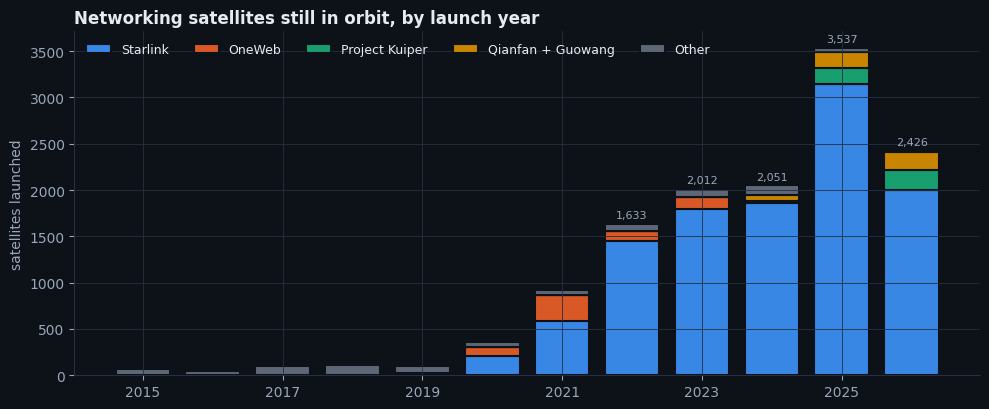

In [4]:
top = ['Starlink', 'OneWeb', 'Project Kuiper']
grp = sat['constellation'].where(sat['constellation'].isin(top),
      np.where(sat['constellation'].isin(['Qianfan (G60)', 'Guowang']), 'Qianfan + Guowang', 'Other'))
years = list(range(2015, int(sat['year'].max()) + 1))
order = top + ['Qianfan + Guowang', 'Other']
cols = CAT[:4] + [OTHER]
fig, ax = plt.subplots(figsize=(10, 4.2))
bottom = np.zeros(len(years))
for name, col in zip(order, cols):
    v = np.array([((grp == name) & (sat['year'] == y)).sum() for y in years])
    ax.bar(years, v, bottom=bottom, color=col, width=.78, label=name, edgecolor=SURF, linewidth=1.5)
    bottom += v
ax.set_title('Networking satellites still in orbit, by launch year')
ax.set_ylabel('satellites launched'); ax.set_xticks(years[::2])
ax.legend(ncol=5, loc='upper left', fontsize=9)
for x, v in zip(years, bottom):
    if v > 1500: ax.text(x, v + 40, f'{int(v):,}', ha='center', va='bottom', color=INK2, fontsize=8)
plt.tight_layout(); plt.show()

## 4. Satellite positions: published elements to a browser

CelesTrak publishes **mean orbital elements** meant for the SGP4 model. Running full SGP4 for
14,000 satellites every animation frame is too slow in JavaScript. So the browser runs a
**Kepler solver with J2 secular drift**: node and perigee precess, and mean anomaly advances
linearly. That costs about 2 ms per frame for every satellite.

A naive version of that model was **kilometres to thousands of kilometres off for Starlink**. The
published mean motion is a Kozai mean value, and low satellites feel drag. The fix is to
**re-epoch every LEO/MEO element set at build time**:

1. Run full SGP4 at a reference time T0 (the build hour) and at T0 + 24 h.
2. Compare the argument of latitude from SGP4 with the simple model at both times.
3. Correct the mean anomaly at T0 and its rate so the two agree. That folds drag and mean-motion
   recovery into one linear term.

Deep-space objects (period over 225 min, i.e. GEO/HEO) keep their published elements with
analytic J2 rates. Each satellite ships as `el = [a, e, i, Ω0, Ω̇, ω0, ω̇, M0, Ṁ]` at epoch `ep`.

The cell below re-implements the browser model in Python and checks it against python-sgp4 on a
sample of satellites.

In [5]:
MU, RE = 398600.4418, 6378.137
def kep(i, t):
    a, e, inc, W0, Wd, w0, wd, M0, Md = SA['el'][i]; dtt = t - SA['ep'][i]
    W, w, M = W0 + Wd * dtt, w0 + wd * dtt, (M0 + Md * dtt) % (2 * math.pi)
    E = M
    for _ in range(8 if e > .1 else 4): E = E - (E - e * math.sin(E) - M) / (1 - e * math.cos(E))
    xp, yp = a * (math.cos(E) - e), a * math.sqrt(1 - e * e) * math.sin(E)
    cW, sW, cw, sw, ci, si = math.cos(W), math.sin(W), math.cos(w), math.sin(w), math.cos(inc), math.sin(inc)
    return np.array([xp * (cW * cw - sW * sw * ci) - yp * (cW * sw + sW * cw * ci),
                     xp * (sW * cw + cW * sw * ci) + yp * (cW * cw * ci - sW * sw),
                     xp * (sw * si) + yp * (cw * si)])

try:
    from sgp4.api import Satrec, jday
    from sgp4 import omm
    import urllib.request
    SV = 'https://raw.githubusercontent.com/satvisorcom/satvisor-data/master/celestrak/json/'
    raw = {}
    for grp_name in ['starlink', 'oneweb', 'kuiper', 'qianfan', 'iridium-NEXT', 'geo']:
        for o in json.loads(urllib.request.urlopen(SV + grp_name + '.json', timeout=60).read()):
            raw.setdefault(o['NORAD_CAT_ID'], o)
    T = D['t0'] + 3 * 3600                        # three hours after the fit
    rng = np.random.default_rng(1); rows = []
    idx = {nid: i for i, nid in enumerate(SA['id'])}
    for nid in rng.choice([n for n in raw if n in idx], 600, replace=False):
        s = Satrec(); omm.initialize(s, raw[nid]); d_ = dt.datetime.fromtimestamp(T, dt.timezone.utc)
        err, r, v = s.sgp4(*jday(d_.year, d_.month, d_.day, d_.hour, d_.minute, d_.second))
        if err: continue
        i = idx[nid]
        rows.append((cn[SA['c'][i]], np.linalg.norm(kep(i, T) - np.array(r))))
    v = pd.DataFrame(rows, columns=['constellation', 'error_km'])
    display(v.groupby('constellation')['error_km'].describe(percentiles=[.5, .9])[['count', '50%', '90%', 'max']].round(1))
    print(f"all: median {v.error_km.median():.1f} km, p90 {v.error_km.quantile(.9):.1f} km")
except Exception as ex:
    print('skipped (needs network + sgp4):', ex)

,count,50%,90%,max
constellation,,,,
Eutelsat GEO,1.0,24.2,24.2,24.2
Intelsat GEO,4.0,28.4,34.5,35.6
Iridium NEXT,7.0,13.3,17.9,19.9
OneWeb,33.0,21.2,28.0,29.3
Other GEO (mixed use),14.0,28.7,31.8,32.0
Project Kuiper,18.0,7.8,11.3,11.5
Qianfan (G60),10.0,21.2,8296.5,14010.0
SES GEO,3.0,27.3,43.5,47.6
Starlink,506.0,9.0,30.4,13609.0


all: median 9.9 km, p90 30.4 km


Across 600 sampled satellites three hours after the fit, the error is typically **about 10 km**.
That's well under one pixel at full-globe zoom. The worst cases are satellites still
orbit-raising after launch, whose along-track motion is not linear. Error grows the further the
clock gets from T0, which is why the refresh runs daily.

**Display radius.** LEO is drawn at 1.2× true altitude scale. Above 2,000 km, altitude is
log-compressed so the GEO belt sits at about 1.8 Earth radii instead of 6.6. There is a
true-scale toggle.

## 5. The similarity map (datamap)

Built with the datamap pipeline (UMAP layout, three HDBSCAN layers, hand-written labels). The
embedding is **structured features, not text**:

- **Satellites:** constellation (one-hot, weight 3), orbit class (weight 2), log altitude,
  inclination (cos/sin), eccentricity and launch year.
- **Ground sites:** site type (one-hot, weight 3), position on the globe as a unit vector, and
  commissioning year.
- An entity block keeps the two groups apart. Features are centred, then tiny noise breaks
  exact ties.

The first UMAP (cosine, `n_neighbors=30`, `min_dist=0.08`) gave tight clusters. HDBSCAN on that
layout gave **12 / 24 / 49 clusters**, each labelled by reading its composition:
constellation, shell, launch year, region. A second, more spread UMAP over the same features
(Euclidean, `min_dist=0.55`) is what the app displays. Cluster membership and labels come from
the first run, and each label sits at its cluster's medoid.

Rows added later (FCC sites, newly launched satellites) are placed at the mean of their six
nearest neighbours in feature space, so the layout and labels stay stable across daily
refreshes.

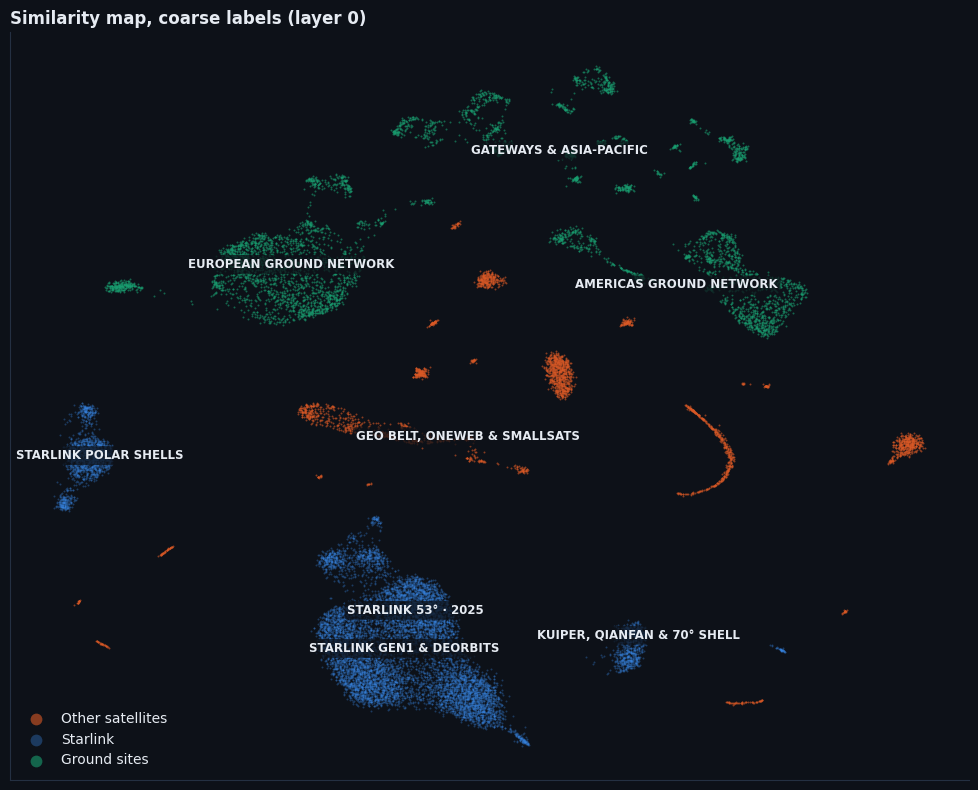

In [6]:
xy_s, xy_g = np.array(SA['xy']), np.array(GS['xy'])
is_sl = np.array([cn[c] == 'Starlink' for c in SA['c']])
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(*xy_s[~is_sl].T, s=2, c=CAT[1], alpha=.6, linewidths=0, label='Other satellites')
ax.scatter(*xy_s[is_sl].T, s=2, c=CAT[0], alpha=.35, linewidths=0, label='Starlink')
ax.scatter(*xy_g.T, s=2, c=CAT[2], alpha=.6, linewidths=0, label='Ground sites')
placed = []   # simple collision avoidance: largest clusters first, skip labels too close to one already drawn
for name, m in sorted(D['label_layers'][0].items(), key=lambda kv: -kv[1]['n']):
    if any((m['x'] - px) ** 2 + ((m['y'] - py) * 2.2) ** 2 < 16 for px, py in placed): continue
    placed.append((m['x'], m['y']))
    ax.text(m['x'], m['y'], name.strip().upper(), ha='center', va='center', fontsize=8.5, weight='bold', color=INK,
            bbox=dict(boxstyle='round,pad=.25', fc=SURF, ec='none', alpha=.75))
ax.set_title('Similarity map, coarse labels (layer 0)'); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.legend(loc='lower left', markerscale=6); plt.tight_layout(); plt.show()

## 6. The ground segment

The ground layer went through four passes, each more authoritative than the last:

1. **Curated professional networks** (116 sites): NASA DSN / Space Network / Near Space Network,
   ESA ESTRACK, KSAT, SSC, AWS Ground Station (region-level), OneWeb and O3b gateways, Iridium,
   Globalstar, major GEO teleports, and the China, ISRO and JAXA networks. Each has a `serves`
   list and a location basis (site / town / region).
2. **Starlink gateways** from a 2025 compilation (198 sites). 117 were geocoded against GeoNames;
   81 small places were placed by hand at town level. **SatNOGS** (4,495 stations, ODbL) and
   Starlink PoPs and community gateways were added as they are.
3. **FCC licences.** 29 filings (`SES-LIC` and `SES-MOD`) were read from ICFS Form 312
   Schedule B, giving exact coordinates, antenna count and size, and every licensed band. These
   were 20 new SpaceX gateways (40 × 2 m antennas; Ka, Q/V, E and W bands), 3 Kuiper gateways
   (6 × 2.4 m, Ka), 5 Northwood Space sites and 1 RBC Signals site. Transcription was checked
   against the live data a second time: 29 of 29 match.
4. **FCC special temporary authorities.** All 280 `SES-STA` filings were read:
   - 98 carried a Schedule B with exact coordinates.
   - 94 were located from the filing description, or the earlier STA it extends (town-level).
   - 17 mobile or test-terminal STAs were skipped.
   - 71 publish no location anywhere.

   The rest collapse to **161 sites**: 78 Starlink gateways, 49 Viasat SANs, 8 Intelsat
   teleports and 26 others. Every newly filed SpaceX gateway also holds a 60-day STA, so those
   show as **operating**, not planned.

**Merging rules:**
- An FCC site within 1.5 km of an existing site of the same operator family is merged into it.
- A town-level 2025 gateway snaps to the filed coordinates when the town matches.
- A new licence next to a live gateway is kept as a second site, unless the STA data shows it
  is the same site (as happened at Lockport NY and Elbert CO).

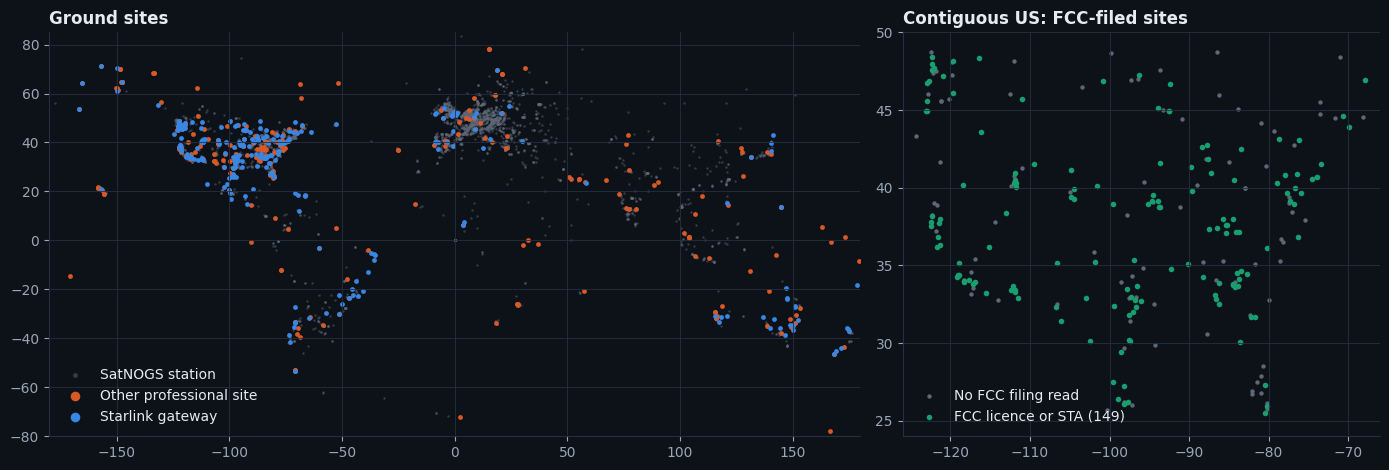

In [7]:
lon, lat, k = np.array(GS['lon']), np.array(GS['lat']), np.array(GS['k'])
fcc = np.array([bool(f) or len(s) > 0 for f, s in zip(GS['fcc'], GS['sta'])])
sn = k == D['kinds'].index('SatNOGS station'); slg = k == D['kinds'].index('Starlink gateway')
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={'width_ratios': [1.7, 1]})
ax = axs[0]
ax.scatter(lon[sn], lat[sn], s=3, c=OTHER, alpha=.5, linewidths=0, label='SatNOGS station')
ax.scatter(lon[~sn & ~slg], lat[~sn & ~slg], s=12, c=CAT[1], linewidths=0, label='Other professional site')
ax.scatter(lon[slg], lat[slg], s=12, c=CAT[0], linewidths=0, label='Starlink gateway')
ax.set_xlim(-180, 180); ax.set_ylim(-80, 85); ax.set_title('Ground sites'); ax.legend(loc='lower left', markerscale=2)
ax = axs[1]; us = (lon > -126) & (lon < -66) & (lat > 24) & (lat < 50)
ax.scatter(lon[us & ~fcc & ~sn], lat[us & ~fcc & ~sn], s=10, c=OTHER, linewidths=0, label='No FCC filing read')
ax.scatter(lon[us & fcc], lat[us & fcc], s=16, c=CAT[2], linewidths=0, label=f'FCC licence or STA ({(us & fcc).sum()})')
ax.set_xlim(-126, -66); ax.set_ylim(24, 50); ax.set_title('Contiguous US: FCC-filed sites'); ax.legend(loc='lower left')
plt.tight_layout(); plt.show()

## 7. The link model

Beams are **a geometric visibility model, not observed traffic.** For each online ground site
and each system it serves, the app picks the highest satellites above the site's elevation mask:

| Site type | Mask | Links |
|---|---|---|
| Starlink gateway / community gateway | 25° | up to 4 |
| Constellation gateway (OneWeb, O3b, Iridium, Globalstar, Kuiper, Viasat SAN) | 10° | up to 4 |
| GEO teleport | 10° | up to 2, **only to its own operator's fleet** |
| TT&C / deep space | 10° | up to 2 |
| SatNOGS station | its own horizon (5–40°) | 1 |

Planned and offline sites draw no links. Military GEO satellites are never teleport link
targets. The cell below recomputes the Starlink gateway links at T0 with the same rule.

In [8]:
T = D['t0']
def eci_all(ids, t): return np.array([kep(i, t) for i in ids])
def gmst(t): jd = t / 86400 + 2440587.5; return math.radians((280.46061837 + 360.98564736629 * (jd - 2451545)) % 360)
th = gmst(T)
sl_ids = [i for i, c in enumerate(SA['c']) if cn[c] == 'Starlink']
X = eci_all(sl_ids, T)                                     # ECI km
gw = np.where(slg & np.isin(np.array(GS['st']), [0, 1, 4]))[0]    # online / testing / unknown gateways
la, lo = np.radians(lat[gw]), np.radians(lon[gw]) + th           # rotate Earth-fixed to ECI
U = np.stack([np.cos(la) * np.cos(lo), np.cos(la) * np.sin(lo), np.sin(la)], 1)
G = U * RE
nvis = []
for u, g in zip(U, G):
    d = X - g; sin_el = (d @ u) / np.linalg.norm(d, axis=1)
    nvis.append(int((sin_el > math.sin(math.radians(25))).sum()))
nvis = np.array(nvis)
print(f"{len(gw)} online Starlink gateways at {dt.datetime.fromtimestamp(T, dt.timezone.utc):%Y-%m-%d %H:%MZ}")
print(f"Starlink satellites above 25° per gateway: median {np.median(nvis):.0f}, min {nvis.min()}, max {nvis.max()}")
print(f"links drawn (4 per gateway where available): {np.minimum(nvis, 4).sum()}")

231 online Starlink gateways at 2026-09-27 09:00Z
Starlink satellites above 25° per gateway: median 63, min 12, max 95
links drawn (4 per gateway where available): 924


## 8. Coverage heatmap

For every shown satellite, the ground circle where it sits above 25° elevation (central angle
λ = acos(Rₑ/r · cos ε) − ε) is added to a 2° grid. Each cell then counts how many satellites a
user there could see. The app recomputes this every 1.5 s, follows the filters, and colours it
with a single amber ramp stretched between the 5th and 99th percentile. Below is the same
computation for Starlink alone and for every networking constellation.

Starlink: median 38, max 105 satellites in view


All networking constellations: median 173, max 309 satellites in view


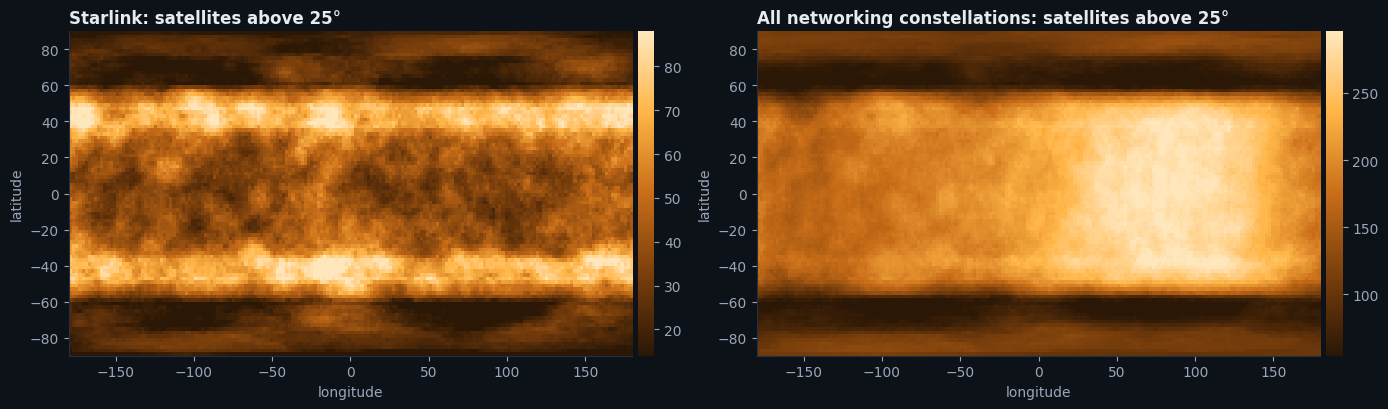

In [9]:
def heat(ids, t, el=25):
    th = gmst(t); H = np.zeros((90, 180)); ce = math.cos(math.radians(el))
    cla, clo = np.meshgrid(np.radians(90 - (np.arange(90) + .5) * 2), np.radians(-180 + (np.arange(180) + .5) * 2), indexing='ij')
    CU = np.stack([np.cos(cla) * np.cos(clo), np.cos(cla) * np.sin(clo), np.sin(cla)], -1)
    for i in ids:
        x, y, z = kep(i, t); r = math.sqrt(x * x + y * y + z * z)
        c, s = math.cos(-th), math.sin(-th); xe, ye = x * c - y * s, x * s + y * c   # to Earth-fixed
        lam = math.acos(min(1, RE / r * ce)) - math.radians(el)
        if lam <= 0: continue
        H += (CU @ np.array([xe, ye, z]) / r) >= math.cos(lam)
    return H
mil = lambda n: n.startswith('USA ') or any(k in n for k in ('MUOS', 'MILSTAR', 'WGS', 'AEHF', 'SBIRS', 'UFO'))
all_ids = [i for i in range(len(SA['id'])) if not mil(SA['name'][i]) and D['orbits'][SA['o'][i]] != 'HEO/GTO']
fig, axs = plt.subplots(1, 2, figsize=(14, 4.2))
for ax, ids, title in [(axs[0], sl_ids, 'Starlink'), (axs[1], all_ids, 'All networking constellations')]:
    H = heat(ids, T); lo_, hi_ = np.percentile(H[H > 0], [5, 99])
    im = ax.imshow(np.clip(H, lo_, hi_), extent=[-180, 180, -90, 90], cmap=AMBER, aspect='auto')
    ax.set_title(f'{title}: satellites above 25°'); ax.grid(False); ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
    cb = fig.colorbar(im, ax=ax, fraction=.03, pad=.01); cb.outline.set_visible(False)
    print(f"{title}: median {np.median(H):.0f}, max {H.max():.0f} satellites in view")
plt.tight_layout(); plt.show()

Starlink's coverage peaks in the mid-latitude bands (about 40–55°), where its 43°, 53° and 70°
shells overlap. It thins toward the equator and at high latitude, where only the polar shells
reach.

## 9. Refresh, hosting and the PWA

- **Daily refresh.** `pipeline/refresh.py` downloads fresh elements, the SATCAT catalogue and the
  Starlink PoPs, rebuilds the master table, re-fits every orbit to the current hour, and writes
  `out/orbital.json`. It refuses a payload with fewer than 10,000 satellites or 4,000 stations.
  In the repository it runs as the GitHub Action `.github/workflows/refresh.yml` every day at
  11:48 UTC, and commits `data/orbital.json` when it changes.
- **Hosting.** GitHub Pages serves the repository root. There is no build step; `.nojekyll`
  makes Pages serve every file as-is.
- **PWA.** `manifest.webmanifest` holds the name, colours, icons (normal and maskable) and
  shortcuts to the similarity view. `sw.js` handles caching:
  - The app shell, textures, three.js and icons are cache-first, under a versioned cache.
  - `data/orbital.json` is network-first, so the daily refresh shows up while the last copy
    still works offline.
  - Google Fonts use stale-while-revalidate.

  three.js is served from the repository rather than a CDN so the app runs fully offline. An
  **Install** button appears when the browser offers installation.
- **Icon.** A globe with a lit limb and graticule, an amber orbit ring, and a satellite with a
  downlink beam to a ground station. Rendered at 4× and downsampled. The maskable versions keep
  the artwork inside the 80% safe zone.
- **QR code.** It points to the Pages URL and was decoded back with OpenCV before delivery.

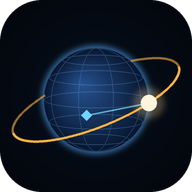

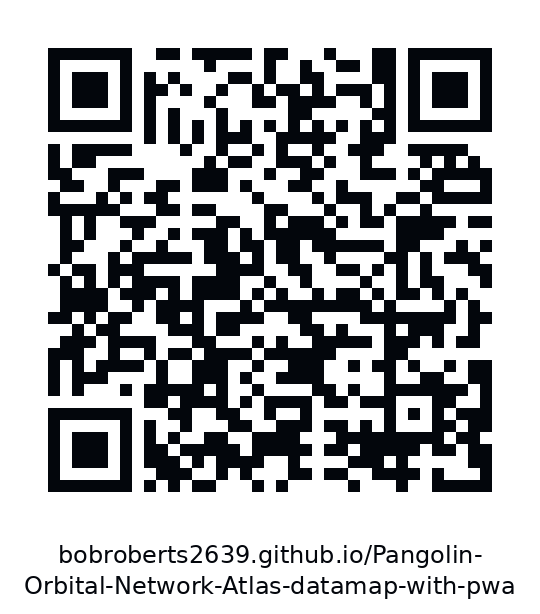

In [10]:
from IPython.display import Image as IPImage, display
display(IPImage(filename=os.path.join(ROOT, 'icons', 'icon-192.png')))
display(IPImage(filename=os.path.join(ROOT, 'qr', 'orbital-network-atlas-qr.png'), width=260))

## 10. Validation and known gaps

**Checked:**
- **Filters:** the shipped JavaScript predicate, run in Chromium, matches independent pandas
  counts in 5 scenarios.
- **Positions:** about 10 km median against SGP4 at T0 + 3 h (section 4).
- **FCC coordinates:** 29 of 29 match the ICFS data on a second read.
- **Rendering:** checked in headless Chromium at desktop and phone widths.
- **Click-through:** a click opens the CelesTrak record in a new tab.

**Gaps:**
1. **Some ground sites are approximate or reported.** This applies to the curated OneWeb, O3b and
   Globalstar gateways, AWS Ground Station (published by region only), the 2025 Starlink list's
   hand-placed towns, and Viasat SANs (their Schedule B is in PDFs). The inspector shows each
   site's location basis.
2. **Beams are modelled.** Real gateway-to-satellite assignment and laser-link topology are not
   public.
3. **Kuiper and the Chinese constellations** have no complete public gateway lists.
4. **Most SatNOGS stations are offline** (about 4,150 of 4,495). They are kept for the build-out
   history.
5. **Positions drift between refreshes:** about 50–120 km after three days for low Starlink
   shells if the refresh stops.

## 11. Rebuilding from scratch

The routine refresh keeps the layout and labels. A full rebuild runs, in order:

- `build_dataset.py`: the master table and structured features.
- The datamap pipeline's `build` with `--embeddings features.npy`: UMAP and HDBSCAN.
- Relabel from the cluster summaries (`summarize.py` prints the composition of each cluster).
- `relayout.py`: the spread display layout.
- Export `layout.json`, `clusters.json` and `layout_ids.json` (the last one via
  `BASE_ONLY=1 python build_dataset.py`).
- `build_payload.py`.

The FCC steps (`sta_merge.py`, `geo_us.py`) need the ICFS pulls in `data/fcc/`. The full rebuild
also needs `umap-learn hdbscan scikit-learn`. Set `RUN_REFRESH = True` below to run the routine
refresh from inside the notebook.

In [11]:
RUN_REFRESH = False
if RUN_REFRESH:
    import shutil, subprocess, tempfile
    work = tempfile.mkdtemp(); shutil.copytree(os.path.join(ROOT, 'pipeline'), work, dirs_exist_ok=True)
    r = subprocess.run([sys.executable, 'refresh.py'], cwd=work, capture_output=True, text=True)
    print(r.stdout[-1500:] or r.stderr[-1500:])
    # shutil.copy(os.path.join(work, 'out', 'orbital.json'), os.path.join(ROOT, 'data', 'orbital.json'))